<a href="https://colab.research.google.com/github/ibtihalalf/Exercises1/blob/main/Week2/Projects/P1_Fast_Food_Marketing_Campaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  A/B Testing for Marketing Campaign Optimization

##  Project Overview
A fast-food chain is planning to introduce a new item to its menu. To maximize sales, the company is testing three different marketing campaigns across multiple locations.

Each location uses a different promotion strategy, and weekly sales data for the new item is collected over four weeks.

##  Objective
The goal of this project is to evaluate the effectiveness of the three marketing campaigns using A/B testing techniques and determine which strategy leads to the highest sales.

##  Scope
In this notebook, we will:
- Explore and clean the dataset
- Perform exploratory data analysis (EDA)
- Conduct statistical hypothesis testing (ANOVA / t-tests)
- Compare campaign performance
- Provide a data-driven recommendation

##  Key Question
Which marketing campaign generates the highest sales for the new product?

In [18]:
# ================================
# Imports
# ================================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import kagglehub
import os # Required for path manipulation
# ================================
# Configuration
# ================================
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# ================================
# Constants
# ================================
ALPHA = 0.05  # significance level

##  Data Loading & Initial Validation

Before proceeding with analysis, we load the dataset and perform basic validation checks.

This step ensures:
- The dataset is loaded correctly
- Columns and data types match expectations
- No structural issues exist

Catching problems early prevents errors later in the analysis.

In [19]:
# ================================
#  Download & Load Dataset
# ================================
DATASET = "chebotinaa/fast-food-marketing-campaign-ab-test"
FILE_NAME = "WA_Marketing-Campaign.csv"

# Download dataset
data_path = kagglehub.dataset_download(DATASET)

# Load CSV
file_path = os.path.join(data_path, FILE_NAME)
df = pd.read_csv(file_path)


Using Colab cache for faster access to the 'fast-food-marketing-campaign-ab-test' dataset.


In [20]:
# ================================
#  Quick Validation
# ================================
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    object 
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB


In [21]:
print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


## Data Cleaning

Before exploring the data, we verify that the dataset is clean and suitable for analysis.

This section focuses on identifying issues such as:
- missing values
- incorrect data types

Cleaning the data first helps ensure that later visualizations and statistical tests are reliable.

In [22]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicated rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64

Duplicated rows: 0

Data types:
MarketID              int64
MarketSize           object
LocationID            int64
AgeOfStore            int64
Promotion             int64
week                  int64
SalesInThousands    float64
dtype: object



It appears there are no missing values in the dataset and our test variable (SalesInThousands) is a numeric datatype. So we should'nt require any further data cleansing.

In [23]:
# number of promotions ran per week
df['week'].value_counts()

,count
week,
1,137
2,137
3,137
4,137


- Each week contains exactly 137 observations.
- The dataset is perfectly balanced across all four weeks.

## Exploratory Data Analysis (EDA)

With the dataset cleaned, we now explore the main variables and compare campaign performance.

The purpose of this section is to:
- understand the distribution of sales
- inspect the balance of promotion groups
- visually compare sales across campaigns

These observations provide context before formal hypothesis testing.

### Descriptive Statistics

We begin by summarizing the numerical variables to establish baseline patterns in the data.

In [24]:
df.describe()

,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,5.715328,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,708.000000,12.000000,3.000000,3.250000,60.477500
max,10.000000,920.000000,28.000000,3.000000,4.000000,99.650000


### Promotion Group Distribution

Before comparing results, we check how observations are distributed across the three promotion groups.
A reasonably balanced distribution supports fair comparison.

In [25]:
df["Promotion"].value_counts().sort_index()

,count
Promotion,
1,172
2,188
3,188


- Promotion groups are slightly imbalanced.
- Promotions 2 and 3 have more observations than Promotion 1.

The difference is small, so comparison between campaigns remains valid.

### Sales Distribution

We visualize the distribution of `SalesInThousands` to better understand its shape, spread, and possible outliers.
This helps assess whether parametric testing methods are appropriate.

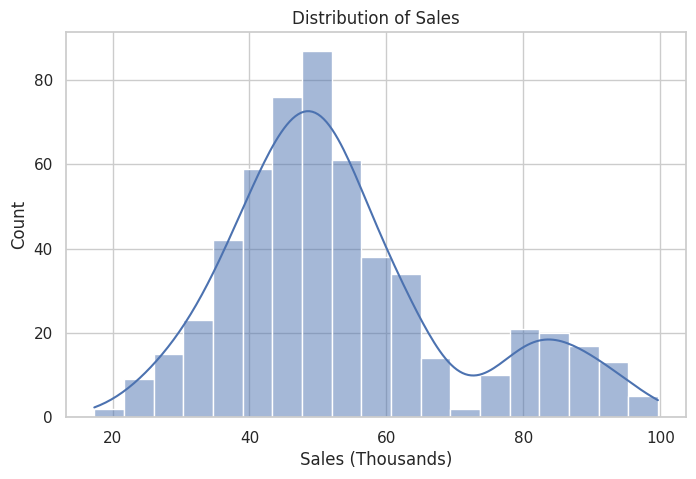

In [26]:
sns.histplot(df["SalesInThousands"], kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales (Thousands)")
plt.ylabel("Count")
plt.show()

- Sales appear roughly centered around the mid-range (≈ 40–60).
- The distribution is slightly right-skewed with a few higher values.
- No extreme outliers are clearly visible.

### Average Sales by Promotion Strategy

The average sales were calculated for each promotion using a group-by operation.

This summary helps compare the overall performance of each campaign and identify which promotion generates higher sales on average.

In [27]:
df.groupby("Promotion")["SalesInThousands"].mean()

,SalesInThousands
Promotion,
1,58.099012
2,47.329415
3,55.364468


The highest avarge sale is promotion 1.

### Sales by Promotion Type

A boxplot allows us to compare the distribution of `SalesInThousands` across the three campaigns.
This visual comparison highlights differences in median sales and potential outliers.

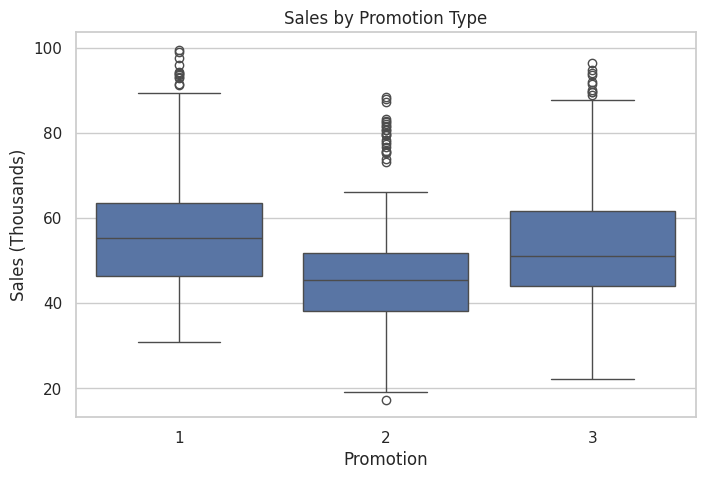

In [28]:
sns.boxplot(x="Promotion", y="SalesInThousands", data=df)
plt.title("Sales by Promotion Type")
plt.xlabel("Promotion")
plt.ylabel("Sales (Thousands)")
plt.show()

### Sales Distribution Insights by Promotion

- Promotion 1 shows the highest median sales.  
- Promotion 2 has the lowest median and a tighter spread.  
- Promotion 3 performs better than Promotion 2 but slightly below Promotion 1.  

The boxplot also reveals the presence of outliers across all promotion strategies, indicating unusually high  sales values in certain weeks.

These differences suggest that campaign performance may vary across promotions, motivating further statistical testing.

## Hypothesis Testing (ANOVA)

To determine whether the differences in sales across the three promotion types are statistically significant, we perform a one-way ANOVA test.

### Hypotheses

- **H0 (Null Hypothesis):** All three promotion strategies have the same impact on weekly sales.
- **H1 (Alternative Hypothesis):** At least one promotion strategy leads to significantly different weekly sales compared to the others.

In [29]:
# Split data by promotion
group1 = df[df["Promotion"] == 1]["SalesInThousands"]
group2 = df[df["Promotion"] == 2]["SalesInThousands"]
group3 = df[df["Promotion"] == 3]["SalesInThousands"]

# Perform ANOVA
f_stat, p_value = stats.f_oneway(group1, group2, group3)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 21.953485793080674
p-value: 6.765849261408714e-10


- The p-value is far below the significance level (0.05).
- Therefore, we reject the null hypothesis.

This suggests that not all promotion strategies perform equally, and at least one campaign has a significantly different impact on weekly sales.

## Analysis (Tukey HSD)

Since ANOVA showed a significant difference between promotion strategies, we perform a Tukey HSD test to identify which specific groups differ.

This test compares all pairs of promotions and determines where the differences lie.

In [30]:
tukey = pairwise_tukeyhsd(
    endog=df["SalesInThousands"],
    groups=df["Promotion"],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------


Results show that Promotion 2 is significantly different from the other two campaigns, while Promotions 1 and 3 perform similarly.

## Recommendation

Promotion 1 is the most effective strategy and should be selected, as it generates the highest sales among the tested campaigns.